# **Bloque 3: El Techo de Rendimiento - CUDA GPU**
### **Asignatura:** Computación de Altas Prestaciones (CAP)
### **Proyecto Final:** Comparativa de aceleración masiva en GPU vs Optimización de CPU.

---

## **1. Preparación del Entorno**
Asegúrate de tener una GPU asignada (T4) en `Entorno de ejecución` > `Cambiar tipo de entorno de ejecución`.

In [1]:
!nvidia-smi

Thu Apr 16 05:10:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [19]:
!pip install nvcc4jupyter

In [20]:
%load_ext nvcc4jupyter

The nvcc4jupyter extension is already loaded. To reload it, use:
  %reload_ext nvcc4jupyter


# **2. SAXPY: ¿Vale la pena arrancar el Autobús?**

### **Contexto: Recordando el Bloque 1**
En el primer notebook, realizamos la operación **SAXPY** ($Y = aX + Y$) utilizando nuestro **Ferrari (la CPU)**. Aprendimos que podíamos acelerar el proceso usando OpenMP para que varios núcleos trabajaran en paralelo. Sin embargo, por muy rápido que sea un Ferrari, solo tiene unos pocos asientos (8 o 16 hilos).

### **El Salto a la GPU: El Autobús Masivo**
Hoy vamos a realizar **exactamente la misma ejecución**, con los mismos tamaños de vectores, pero vamos a cambiar de vehículo: la **GPU (el Autobús)**.

### **Tu Reto: El Kernel y el Control de Límites**
En la programación de GPUs, lanzamos un número de hilos que suele ser múltiplo de 32 (el tamaño de un *warp*). Esto significa que, casi siempre, **lanzaremos más hilos de los que realmente necesitamos**.

> **Instrucción importante:** Debes desarrollar el kernel `saxpy_kernel`. Ten especial cuidado en **implementar un control de seguridad** para que los hilos sobrantes no intenten acceder a posiciones de memoria fuera del vector ($i \geq n$), lo cual causaría errores graves o resultados corruptos.


### **2.1 Implementación en CUDA (saxpy.cu)**

In [21]:
%%writefile saxpy.cu
// lenguaje: c++
#include <stdio.h>
#include <cuda_runtime.h>
#include <stdlib.h>

__global__ void saxpy_kernel(int n, float a, float *x, float *y) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        y[i] = a * x[i] + y[i];
    }
}

int main(int argc, char** argv) {
    if (argc < 2) return 1;
    int n = atoi(argv[1]);
    size_t size = n * sizeof(float);

    float *h_x = (float*)malloc(size), *h_y = (float*)malloc(size);

    for (int i = 0; i < n; i++) { h_x[i] = 1.0f; h_y[i] = 2.0f; }

    float *d_x, *d_y;
    cudaMalloc(&d_x, size);
    cudaMalloc(&d_y, size);

    cudaMemcpy(d_x, h_x, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_y, h_y, size, cudaMemcpyHostToDevice);

    int threads = 256;
    int blocks = (n + threads - 1) / threads;

    // --- WARM UP ---
    saxpy_kernel<<<blocks, threads>>>(n, 2.0f, d_x, d_y);
    cudaDeviceSynchronize();

    // --- MEDICIÓN ---
    cudaEvent_t start, stop; cudaEventCreate(&start); cudaEventCreate(&stop);
    cudaEventRecord(start);
    saxpy_kernel<<<blocks, threads>>>(n, 2.0f, d_x, d_y);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float ms; cudaEventElapsedTime(&ms, start, stop);

    // Imprimimos el tiempo por stderr para evitar ruidos de compilación
    fprintf(stderr, "%f", ms);

    cudaFree(d_x); cudaFree(d_y); free(h_x); free(h_y);
    return 0;
}

Overwriting saxpy.cu


In [22]:
import subprocess
import re

# Compilación
!nvcc -O3 saxpy.cu -o saxpy_cuda

def run_saxpy(n):
    # Capturamos stderr que es donde enviamos el tiempo
    p = subprocess.Popen(['./saxpy_cuda', str(n)], stderr=subprocess.PIPE, stdout=subprocess.PIPE)
    _, err = p.communicate()
    # Usamos regex para encontrar el float incluso si hay texto extra
    match = re.search(r"[-+]?\d*\.\d+|\d+", err.decode())
    return float(match.group()) if match else 0.0

sizes = [10**4, 10**5, 10**6, 10**7]
print(f"{'N (Elementos)':<15} | {'Tiempo GPU (ms)':<15}")
print("-" * 35)

for n in sizes:
    t = run_saxpy(n)
    print(f"{n:<15} | {t:<15.4f}")

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
N (Elementos)   | Tiempo GPU (ms)
-----------------------------------
10000           | 0.0083         
100000          | 0.0143         
1000000         | 0.0531         
10000000        | 0.4711         


# **3. Multiplicación de Matrices (GEMM): El Motor de la IA**

### **Contexto: ¿Por qué es el ejercicio más importante?**
La multiplicación de matrices no es solo un problema de álgebra; es la operación que hace funcionar casi todo en la computación moderna, desde los gráficos de videojuegos hasta el entrenamiento de Redes Neuronales y Grandes Modelos de Lenguaje (LLMs). Si puedes multiplicar matrices rápido, puedes hacer IA rápida.

### **El Problema del "Caché Miss" en CPU**
En la multiplicación de matrices tradicional ($C = A \times B$), la CPU sufre mucho. Para calcular un solo elemento de la matriz resultante, tiene que recorrer una fila de $A$ y una columna de $B$.
* **Recorrer filas:** Es rápido (acceso secuencial).
* **Recorrer columnas:** Es lentísimo (la CPU tiene que saltar grandes distancias en la memoria), lo que provoca que la memoria caché falle constantemente.

### **La Fuerza Bruta de CUDA**
En este ejercicio, vamos a comparar tres enfoques:
1.  **CPU ijk:** La implementación ingenua y más lenta.
2.  **CPU ikj:** Una optimización simple que mejora el uso de la caché al acceder de forma más secuencial.
3.  **GPU (CUDA):** Lanzaremos un hilo por cada celda de la matriz resultante. Mientras la CPU calcula un elemento a la vez, la GPU calculará miles simultáneamente.



### **3.1 Implementación en CUDA (matmul.cu)**

**Instrucciones:** Desarrolla el kernel `matmul_kernel`. Cada hilo debe identificar su fila (`row`) y su columna (`col`), realizar el producto escalar de la fila de $A$ por la columna de $B$, y guardar el resultado en la posición correspondiente de la matriz $C$.

> **Nota Técnica:** Observa cómo al escalar el tamaño de la matriz ($N$), el tiempo de la CPU crece de forma cúbica ($O(N^3)$), mientras que la GPU aguanta el tipo mucho mejor gracias a su inmenso ancho de banda y paralelismo.

In [23]:
%%writefile matmul_bench.cu
#include <stdio.h>
#include <stdlib.h>
#include <time.h> // Para medir tiempos en CPU

void matmul_ijk(float *A, float *B, float *C, int N) {
    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            float sum = 0.0f;
            for (int k = 0; k < N; k++) {
                sum += A[i * N + k] * B[k * N + j];
            }
            C[i * N + j] = sum;
        }
    }
}


void matmul_ikj(float *A, float *B, float *C, int N) {
    for (int i = 0; i < N; i++) {
        for (int k = 0; k < N; k++) {
            float a_ik = A[i * N + k];
            for (int j = 0; j < N; j++) {
                C[i * N + j] += a_ik * B[k * N + j];
            }
        }
    }
}


__global__ void matmul_kernel(float *A, float *B, float *C, int N) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < N && col < N) {
        float sum = 0.0f;
        for (int k = 0; k < N; k++) {
            sum += A[row * N + k] * B[k * N + col];
        }
        C[row * N + col] = sum;
    }
}

int main(int argc, char** argv) {
    // Verificación de argumentos de entrada
    if (argc < 3) {
        fprintf(stderr, "Uso: %s <N> <modo>\n", argv[0]);
        fprintf(stderr, "  N: Dimensión de las matrices (N x N)\n");
        fprintf(stderr, "  modo: 0=CPU_ijk, 1=CPU_ikj, 2=GPU\n");
        return 1;
    }

    int N = atoi(argv[1]); // Dimensión de las matrices (N x N)
    int mode = atoi(argv[2]); // Modo de ejecución: 0=ijk, 1=ikj, 2=GPU
    size_t size = N * N * sizeof(float); // Tamaño total en bytes para una matriz N x N

    // 1. Asignación de memoria en el Host (RAM de la CPU)
    float *h_A = (float*)malloc(size); // Matriz A en Host
    float *h_B = (float*)malloc(size); // Matriz B en Host
    float *h_C = (float*)calloc(N*N, sizeof(float)); // Matriz C en Host, inicializada a 0 con calloc

    // NOTA: Para un benchmark puro de rendimiento, no inicializamos las matrices h_A y h_B
    // con valores específicos aquí, ya que la inicialización no es parte del tiempo de cómputo.
    // En una aplicación real, se inicializarían los datos de entrada aquí.

    // --- Modo GPU ---
    if (mode == 2) {
        // 2. Asignación de memoria en el Device (VRAM de la GPU)
        float *d_A, *d_B, *d_C;
        cudaMalloc(&d_A, size); // Matriz A en Device
        cudaMalloc(&d_B, size); // Matriz B en Device
        cudaMalloc(&d_C, size); // Matriz C en Device (para el resultado)

        // Inicializamos d_C a 0 en la GPU
        cudaMemset(d_C, 0, size);

        // 3. Copia de datos del Host a la Device (h_A -> d_A, h_B -> d_B)
        // Solo copiamos las matrices de entrada. d_C se calculará en la GPU.
        cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
        cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);

        // 4. Configuración de la rejilla (grid) y el bloque (block) para el kernel.
        // Cada bloque de hilos tendrá 16x16 hilos (threadIdx.x, threadIdx.y).
        dim3 block(16, 16);
        // La rejilla se calcula para que cubra toda la matriz N x N.
        // La división (N + block_dim - 1) / block_dim asegura que se cubra toda la dimensión,
        // incluso si N no es un múltiplo exacto de block_dim.
        dim3 grid((N + block.x - 1) / block.x, (N + block.y - 1) / block.y);

        // 5. Medición del tiempo de ejecución del kernel CUDA
        cudaEvent_t s, e; // Eventos para medir el tiempo en la GPU
        cudaEventCreate(&s);
        cudaEventCreate(&e);

        cudaEventRecord(s); // Iniciar el contador de tiempo en la GPU
        matmul_kernel<<<grid, block>>>(d_A, d_B, d_C, N); // Lanzar el kernel en la GPU
        cudaEventRecord(e); // Detener el contador de tiempo en la GPU

        // Esperar a que la GPU termine todas las operaciones antes de leer el tiempo.
        cudaEventSynchronize(e);

        float ms; // Variable para almacenar el tiempo en milisegundos
        // Calcular el tiempo transcurrido entre los eventos 's' y 'e'.
        cudaEventElapsedTime(&ms, s, e);
        printf("%f", ms); // Imprimir el tiempo en stderr para el benchmark.

        // NOTA: No copiamos d_C de vuelta a h_C para este benchmark, ya que solo nos interesa el tiempo de cómputo.
        // Si quisiéramos verificar el resultado, usaríamos: cudaMemcpy(h_C, d_C, size, cudaMemcpyDeviceToHost);

        // 6. Liberar memoria asignada en la Device (GPU)
        cudaFree(d_A);
        cudaFree(d_B);
        cudaFree(d_C);
    } else { // --- Modos CPU (ijk e ikj) ---
        struct timespec s, e; // Estructuras para medir el tiempo en CPU
        // Iniciar el contador de tiempo en CPU
        clock_gettime(CLOCK_MONOTONIC, &s);

        if (mode == 0) { // Ejecutar la versión ijk de CPU
            matmul_ijk(h_A, h_B, h_C, N);
        } else { // Ejecutar la versión ikj (optimizada) de CPU
            matmul_ikj(h_A, h_B, h_C, N);
        }

        // Detener el contador de tiempo en CPU
        clock_gettime(CLOCK_MONOTONIC, &e);

        // Calcular el tiempo transcurrido en milisegundos para la CPU
        printf("%f", (e.tv_sec - s.tv_sec) * 1000.0 + (e.tv_nsec - s.tv_nsec) / 1e6);
    }

    // 7. Liberar memoria asignada en el Host (CPU)
    free(h_A);
    free(h_B);
    free(h_C);

    return 0;
}

Overwriting matmul_bench.cu


Compilando matmul_bench.cu...
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).

Iniciando Benchmark...
Probando N = 128... ✓ OK
Probando N = 256... ✓ OK
Probando N = 512... ✓ OK
Probando N = 1024... ✓ OK


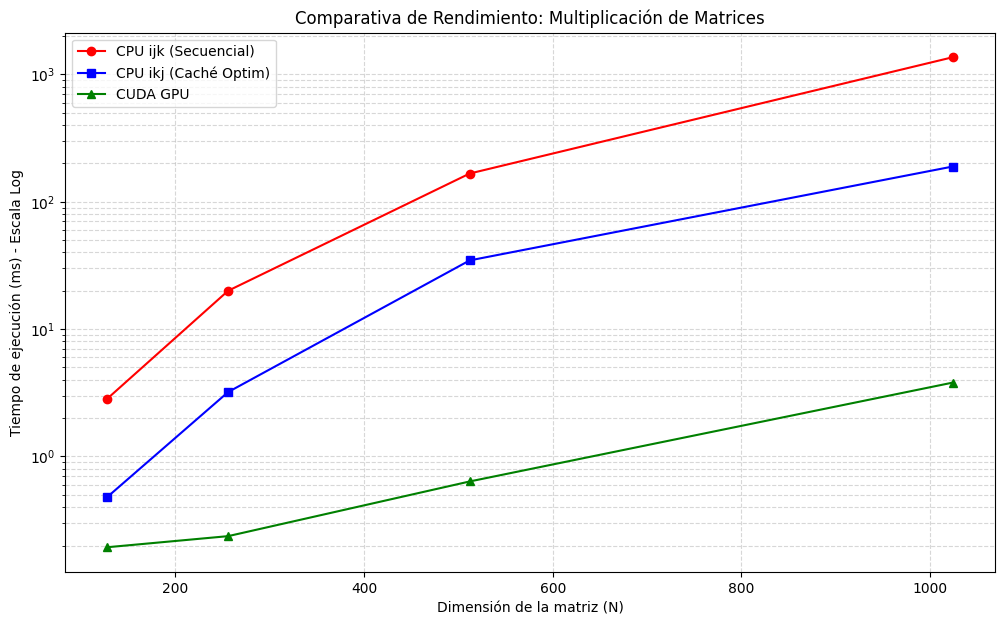


Resultados para N=1024:
🚀 Speedup CPU ikj vs ijk: 7.21x
🔥 Speedup GPU vs CPU ijk: 358.34x


In [25]:
import subprocess
import re
import matplotlib.pyplot as plt

# 1. COMPILACIÓN
print("Compilando matmul_bench.cu...")
!nvcc -O3 matmul_bench.cu -o matmul_bench

# 2. CONFIGURACIÓN DEL EXPERIMENTO
# Tamaños de matriz N x N a probar
N_sizes = [128, 256, 512, 1024]
# Reiniciamos diccionarios para evitar "datos fantasma" de ejecuciones previas
tiempos_gemm = {
    "CPU ijk": [],
    "CPU ikj (Optim)": [],
    "CUDA GPU": []
}

def medir_tiempo(n, modo):
    try:
        # Ejecutamos el binario: ./matmul_bench <N> <modo>
        # modo: 0=ijk, 1=ikj, 2=GPU
        p = subprocess.Popen(['./matmul_bench', str(n), str(modo)],
                             stdout=subprocess.PIPE,
                             stderr=subprocess.PIPE)
        out, err = p.communicate()

        # Leemos la salida (el tiempo en ms)
        salida = out.decode().strip()
        match = re.search(r"[-+]?\d*\.\d+|\d+", salida)

        if match:
            return float(match.group())
        else:
            return None
    except Exception as e:
        print(f"Error en ejecución: {e}")
        return None

# 3. EJECUCIÓN DE LOS TESTS
print("\nIniciando Benchmark...")
for n in N_sizes:
    print(f"Probando N = {n}...", end=" ")

    # Modo 0: CPU ijk
    t_ijk = medir_tiempo(n, 0)
    # Modo 1: CPU ikj
    t_ikj = medir_tiempo(n, 1)
    # Modo 2: CUDA GPU
    t_gpu = medir_tiempo(n, 2)

    if all(v is not None for v in [t_ijk, t_ikj, t_gpu]):
        tiempos_gemm["CPU ijk"].append(t_ijk)
        tiempos_gemm["CPU ikj (Optim)"].append(t_ikj)
        tiempos_gemm["CUDA GPU"].append(t_gpu)
        print("✓ OK")
    else:
        print("✗ ERROR en alguna versión")

# 4. GENERACIÓN DE LA GRÁFICA (Solo si las listas están completas)
if all(len(lista) == len(N_sizes) for lista in tiempos_gemm.values()):
    plt.figure(figsize=(12, 7))

    plt.plot(N_sizes, tiempos_gemm["CPU ijk"], 'r-o', label='CPU ijk (Secuencial)')
    plt.plot(N_sizes, tiempos_gemm["CPU ikj (Optim)"], 'b-s', label='CPU ikj (Caché Optim)')
    plt.plot(N_sizes, tiempos_gemm["CUDA GPU"], 'g-^', label='CUDA GPU')

    plt.xscale('linear')
    plt.yscale('log') # Escala logarítmica para ver bien la diferencia abismal
    plt.xlabel('Dimensión de la matriz (N)')
    plt.ylabel('Tiempo de ejecución (ms) - Escala Log')
    plt.title('Comparativa de Rendimiento: Multiplicación de Matrices')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend()

    plt.show()

    # Imprimir Speedup final para el tamaño más grande
    s_optim = tiempos_gemm["CPU ijk"][-1] / tiempos_gemm["CPU ikj (Optim)"][-1]
    s_gpu = tiempos_gemm["CPU ijk"][-1] / tiempos_gemm["CUDA GPU"][-1]
    print(f"\nResultados para N={N_sizes[-1]}:")
    print(f"🚀 Speedup CPU ikj vs ijk: {s_optim:.2f}x")
    print(f"🔥 Speedup GPU vs CPU ijk: {s_gpu:.2f}x")
else:
    print("\n⚠️ AVISO: No se han recolectado suficientes datos para generar la gráfica.")
    print("Asegúrate de que el código C++ compila y los kernels se ejecutan correctamente.")

# **4. Caso Práctico Visual 1: Test de Lenna (CPU vs GPU)**

### **Contexto: ¿Por qué usar imágenes?**
Una imagen no es más que una **matriz de píxeles**. En una imagen a color (RGB), cada píxel tiene 3 valores: Rojo, Verde y Azul. Procesar una imagen Full HD implica manipular más de 2 millones de puntos simultáneamente, lo que convierte este campo en el escenario ideal para el paralelismo masivo de CUDA.

### **El Objetivo: Conversión a Escala de Grises**
Para convertir una imagen a blanco y negro, no basta con hacer la media aritmética. El ojo humano es más sensible al verde que al azul. Por ello, aplicaremos la fórmula de luminosidad estándar:
$$Y = 0.299R + 0.587G + 0.114B$$

### **La Estrategia en GPU**
A diferencia de la CPU, que procesaría los píxeles uno a uno (o en pequeños grupos), en CUDA vamos a:
1.  **Mapear un hilo por cada píxel:** Cada hilo de la GPU se encargará de leer los valores R, G y B de "su" píxel, aplicar la fórmula y escribir el resultado.
2.  **Organización 2D:** Utilizaremos estructuras `dim3` para organizar los hilos en bloques de dos dimensiones (ej. 16x16), facilitando el acceso a las coordenadas $(x, y)$ de la imagen.



### **4.1 Implementación en CUDA (lenna_gray.cu)**

**Instrucciones:** Completa el kernel `gray_kernel`. Recuerda que la imagen de entrada está "aplanada" en memoria (1D), por lo que deberás calcular el índice correcto usando la fórmula: `idx = (y * ancho + x) * 3`.

In [26]:
%%writefile image_comp.cu
#include <stdio.h>
#include <cuda_runtime.h>
#include <stdlib.h>
#include <time.h>

void grayscale_cpu(unsigned char* out, unsigned char* in, int w, int h) {
    for (int i = 0; i < w * h; i++) {
        int idx = i * 3;
        unsigned char gray = (unsigned char)(0.299f*in[idx] + 0.587f*in[idx+1] + 0.114f*in[idx+2]);
        out[idx] = out[idx+1] = out[idx+2] = gray;
    }
}


__global__ void grayscale_kernel(unsigned char* d_out, unsigned char* d_in, int w, int h) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x < w && y < h) {
        int idx = (y * w + x) * 3;
        unsigned char gray = (unsigned char)(0.299f * d_in[idx]
                                           + 0.587f * d_in[idx + 1]
                                           + 0.114f * d_in[idx + 2]);
        d_out[idx] = d_out[idx+1] = d_out[idx+2] = gray;
    }
}

int main(int argc, char** argv) {
    if (argc < 4) return 1;
    int w = atoi(argv[1]);
    int h = atoi(argv[2]);
    int mode = atoi(argv[3]);
    int size = w * h * 3;

    unsigned char *h_in = (unsigned char*)malloc(size);
    unsigned char *h_out = (unsigned char*)malloc(size);
    if (fread(h_in, sizeof(unsigned char), size, stdin) != size) return 1;

    float ms = 0;
    if (mode == 1) { // MODO GPU
        unsigned char *d_in, *d_out;
        cudaMalloc(&d_in, size); cudaMalloc(&d_out, size);
        cudaMemcpy(d_in, h_in, size, cudaMemcpyHostToDevice);

        dim3 block(16, 16);
        dim3 grid((w + 15) / 16, (h + 15) / 16);

        // --- WARM UP (Calentamiento) ---
        // Lanzamos el kernel una vez sin medir para inicializar el hardware
        grayscale_kernel<<<grid, block>>>(d_out, d_in, w, h);
        cudaDeviceSynchronize();

        // --- MEDICIÓN REAL ---
        cudaEvent_t s, e; cudaEventCreate(&s); cudaEventCreate(&e);
        cudaEventRecord(s);
        grayscale_kernel<<<grid, block>>>(d_out, d_in, w, h);
        cudaEventRecord(e);
        cudaEventSynchronize(e);
        cudaEventElapsedTime(&ms, s, e);

        cudaMemcpy(h_out, d_out, size, cudaMemcpyDeviceToHost);
        cudaFree(d_in); cudaFree(d_out);
    } else { // MODO CPU (El Ferrari no suele necesitar warm-up, pero medimos igual)
        struct timespec s, e;
        clock_gettime(CLOCK_MONOTONIC, &s);
        grayscale_cpu(h_out, h_in, w, h);
        clock_gettime(CLOCK_MONOTONIC, &e);
        ms = (e.tv_sec - s.tv_sec) * 1000.0 + (e.tv_nsec - s.tv_nsec) / 1e6;
    }

    fprintf(stderr, "%f", ms);
    fwrite(h_out, sizeof(unsigned char), size, stdout);
    free(h_in); free(h_out);
    return 0;
}

Overwriting image_comp.cu


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Procesando imagen...


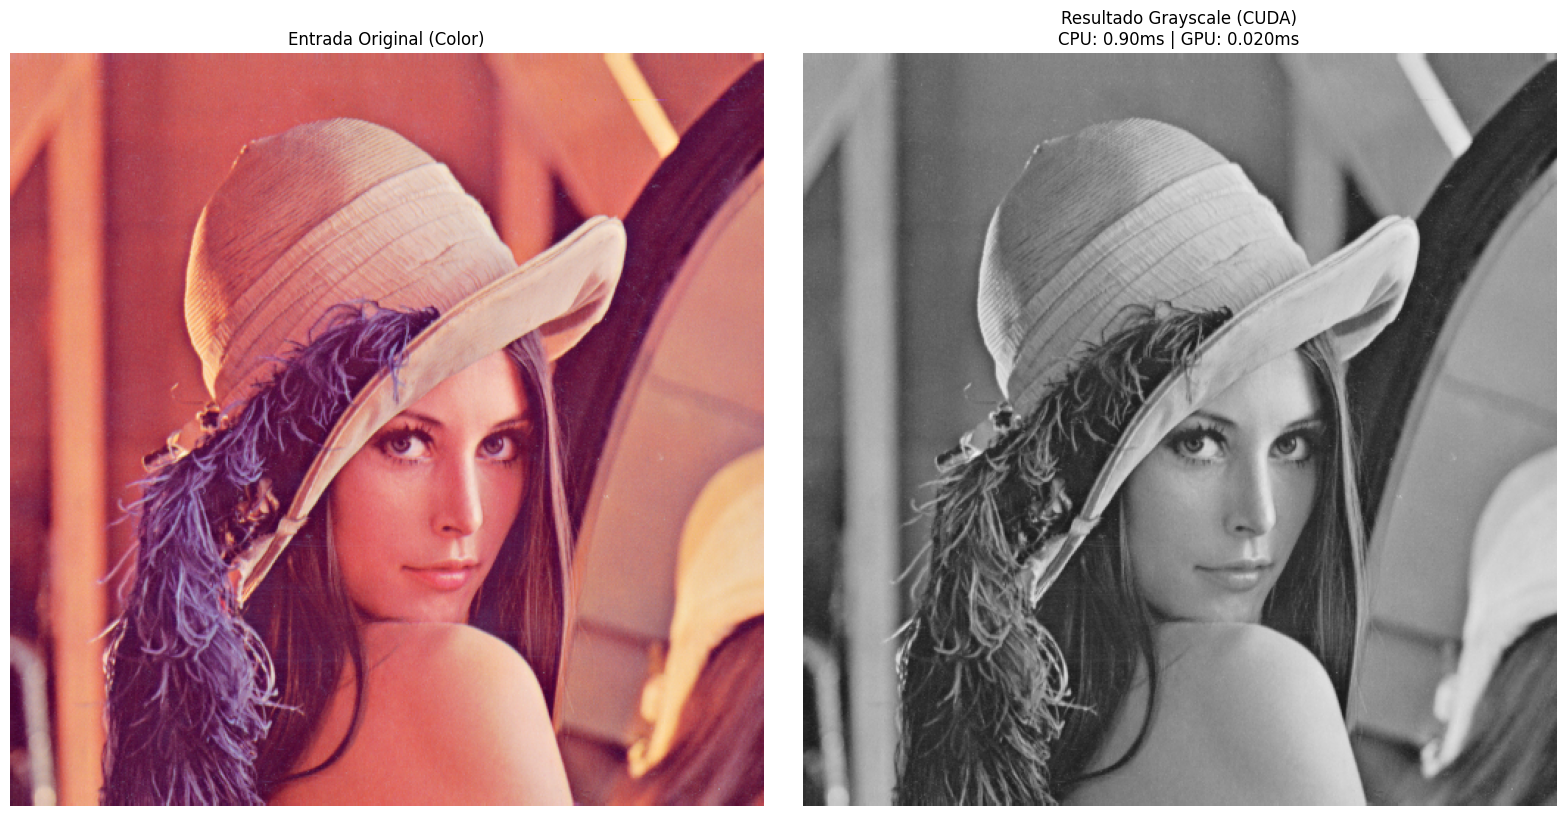


🚀 Speedup en procesamiento de imagen: 46.12x


In [27]:
import subprocess
import requests
import io
import matplotlib.pyplot as plt
from PIL import Image
import os

# 1. COMPILACIÓN
!nvcc -O3 image_comp.cu -o image_comp

# 2. DESCARGA ROBUSTA DE LENNA
# Wikipedia a veces bloquea 'requests', usamos wget como alternativa segura
!wget -q -O lenna.png https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png

if os.path.exists("lenna.png"):
    img = Image.open("lenna.png").convert("RGB")
    width, height = img.size
    img_bytes = img.tobytes()
else:
    raise FileNotFoundError("No se pudo descargar la imagen de Lenna.")

def procesar_imagen(modo):
    # Abrimos el proceso: modo 0=CPU, modo 1=GPU
    p = subprocess.Popen(['./image_comp', str(width), str(height), str(modo)],
                         stdin=subprocess.PIPE, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

    # Enviamos los bytes de la imagen y recibimos el resultado
    stdout_data, stderr_data = p.communicate(input=img_bytes)

    # El tiempo viene por stderr (lo definimos así en el .cu para no ensuciar la imagen)
    try:
        t_ms = float(stderr_data.decode().strip())
    except:
        t_ms = 0.0
    return stdout_data, t_ms

# 3. EJECUCIÓN
print("Procesando imagen...")
raw_cpu, t_cpu = procesar_imagen(0)
raw_gpu, t_gpu = procesar_imagen(1)

# 4. RECONSTRUCCIÓN Y MUESTRA
img_res = Image.frombytes("RGB", (width, height), raw_gpu)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Entrada Original (Color)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_res)
plt.title(f"Resultado Grayscale (CUDA)\nCPU: {t_cpu:.2f}ms | GPU: {t_gpu:.3f}ms")
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"\n🚀 Speedup en procesamiento de imagen: {t_cpu/t_gpu:.2f}x")

## **5. Caso Práctico Visual 2: Generación del Fractal de Mandelbrot**

### **Contexto: Cómputo Intensivo vs Cómputo Ligero**
En el ejercicio anterior (Lenna Grayscale), cada hilo de la GPU realizaba una operación matemática muy sencilla (una suma ponderada de 3 valores) por cada píxel. La GPU era más rápida, pero el cuello de botella era el movimiento de datos (mover los píxeles de la RAM a la VRAM).

### **El Reto del Fractal**
Ahora vamos a generar una imagen desde cero. No vamos a mover píxeles de entrada; vamos a **calcular** el color de cada píxel basándonos en matemáticas complejas.

#### **La Matemática del Caos**
El Conjunto de Mandelbrot se genera iterando la siguiente función para cada punto $C$ (que representa un píxel) del plano complejo:

$$Z_{n+1} = Z_n^2 + C$$

* **¿Cómo funciona?** Empezamos con $Z_0 = 0$. En cada iteración, elevamos el número al cuadrado y le sumamos el valor del punto original $C$.
* **¿Cuándo paramos?** Repetimos esto hasta que el número se "escape" (su magnitud sea mayor a 2) o alcancemos el límite de iteraciones (por ejemplo, 500).
* **El resultado:** Si el número nunca escapa, el punto es **negro** (pertenece al conjunto). Si escapa, le asignamos un **color** dependiendo de qué tan rápido lo hizo.

### **Por qué la GPU "humilla" a la CPU aquí**
* **Intensidad de Cómputo:** Este problema es puro cálculo. Las GPUs T4 de Colab tienen miles de núcleos especializados en operaciones de punto flotante.
* **Independencia:** El color del píxel (0,0) no depende para nada del píxel (0,1). Podemos lanzar 2 millones de hilos (para una imagen Full HD) y cada uno calculará su iteración sin esperar a nadie.


### **5.1 Implementación en CUDA (mandelbrot_color.cu)**

El kernel ya está completamente implementado. Tanto `mandelbrot_cpu` como `mandelbrot_kernel` están listos para ejecutarse. La sección de reto creativo (5.3) te invita a modificar la función `get_color`.

In [28]:
%%writefile mandelbrot_color.cu
// lenguaje: c++
#include <stdio.h>
#include <cuda_runtime.h>
#include <stdlib.h>
#include <math.h>
#include <time.h>

struct Complex {
    float r, i;
    __host__ __device__ Complex(float r, float i) : r(r), i(i) {}
    __host__ __device__ Complex operator+(Complex b) { return Complex(r + b.r, i + b.i); }
    __host__ __device__ Complex operator*(Complex b) { return Complex(r * b.r - i * b.i, r * b.i + i * b.r); }
    __host__ __device__ float magnitude2() { return r * r + i * i; }
};

// Función de mapeo de color psicodélico
// RETO CREATIVO: Modifica las frecuencias y fases para cambiar la paleta.
// Prueba: frecuencia 1.5f para el fractal eléctrico, o pon *g=0 para fuego.
__host__ __device__ void get_color(int iter, int max_iters, unsigned char* r, unsigned char* g, unsigned char* b) {
    if (iter == max_iters) {
        *r = *g = *b = 0; // El centro del conjunto es negro
    } else {
        // Usamos funciones seno con diferentes fases para crear un arcoíris
        float t = (float)iter / 10.0f; // Escala para la velocidad del color
        *r = (unsigned char)(sinf(0.3f * t + 0.0f) * 127 + 128);
        *g = (unsigned char)(sinf(0.3f * t + 2.0f) * 127 + 128);
        *b = (unsigned char)(sinf(0.3f * t + 4.0f) * 127 + 128);
    }
}

void mandelbrot_cpu(unsigned char* out, int w, int h, int max_iters) {
    for (int y = 0; y < h; y++) {
        for (int x = 0; x < w; x++) {
            float cr = -2.0f + 3.0f * x / w;
            float ci = -1.2f + 2.4f * y / h;
            Complex c(cr, ci); Complex z(0, 0);
            int iter = 0;
            while (z.magnitude2() < 4.0f && iter < max_iters) {
                z = z * z + c; iter++;
            }
            int idx = (y * w + x) * 3;
            get_color(iter, max_iters, &out[idx], &out[idx+1], &out[idx+2]);
        }
    }
}

__global__ void mandelbrot_kernel(unsigned char* d_out, int w, int h, int max_iters) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x < w && y < h) {
        float cr = -2.0f + 3.0f * x / w;
        float ci = -1.2f + 2.4f * y / h;
        Complex c(cr, ci); Complex z(0, 0);
        int iter = 0;
        while (z.magnitude2() < 4.0f && iter < max_iters) {
            z = z * z + c; iter++;
        }
        int idx = (y * w + x) * 3;
        get_color(iter, max_iters, &d_out[idx], &d_out[idx+1], &d_out[idx+2]);
    }
}

int main(int argc, char** argv) {
    int w = atoi(argv[1]), h = atoi(argv[2]), max_iters = atoi(argv[3]), mode = atoi(argv[4]);
    int size = w * h * 3;
    unsigned char *h_out = (unsigned char*)malloc(size);
    if (mode == 1) {
        unsigned char *d_out; cudaMalloc(&d_out, size);
        dim3 block(16, 16); dim3 grid((w+15)/16, (h+15)/16);
        // --- Warm-up ---
        mandelbrot_kernel<<<grid, block>>>(d_out, w, h, max_iters);
        cudaDeviceSynchronize();
        // --- Medición ---
        cudaEvent_t s, e; cudaEventCreate(&s); cudaEventCreate(&e); cudaEventRecord(s);
        mandelbrot_kernel<<<grid, block>>>(d_out, w, h, max_iters);
        cudaEventRecord(e); cudaEventSynchronize(e); float ms; cudaEventElapsedTime(&ms, s, e);
        fprintf(stderr, "%f", ms);
        cudaMemcpy(h_out, d_out, size, cudaMemcpyDeviceToHost);
        cudaFree(d_out);
    } else {
        struct timespec s, e; clock_gettime(CLOCK_MONOTONIC, &s);
        mandelbrot_cpu(h_out, w, h, max_iters);
        clock_gettime(CLOCK_MONOTONIC, &e);
        fprintf(stderr, "%f", (e.tv_sec-s.tv_sec)*1000.0 + (e.tv_nsec-s.tv_nsec)/1e6);
    }
    fwrite(h_out, sizeof(unsigned char), size, stdout);
    return 0;
}

Overwriting mandelbrot_color.cu


## 5.2 Orquestación y Visualización (Python)
Ejecuta esta celda para compilar tu kernel, generar el fractal en Full HD y comparar los tiempos. ¡Prepárate para ver un speedup de tres cifras!

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Generando Mandelbrot en Color...


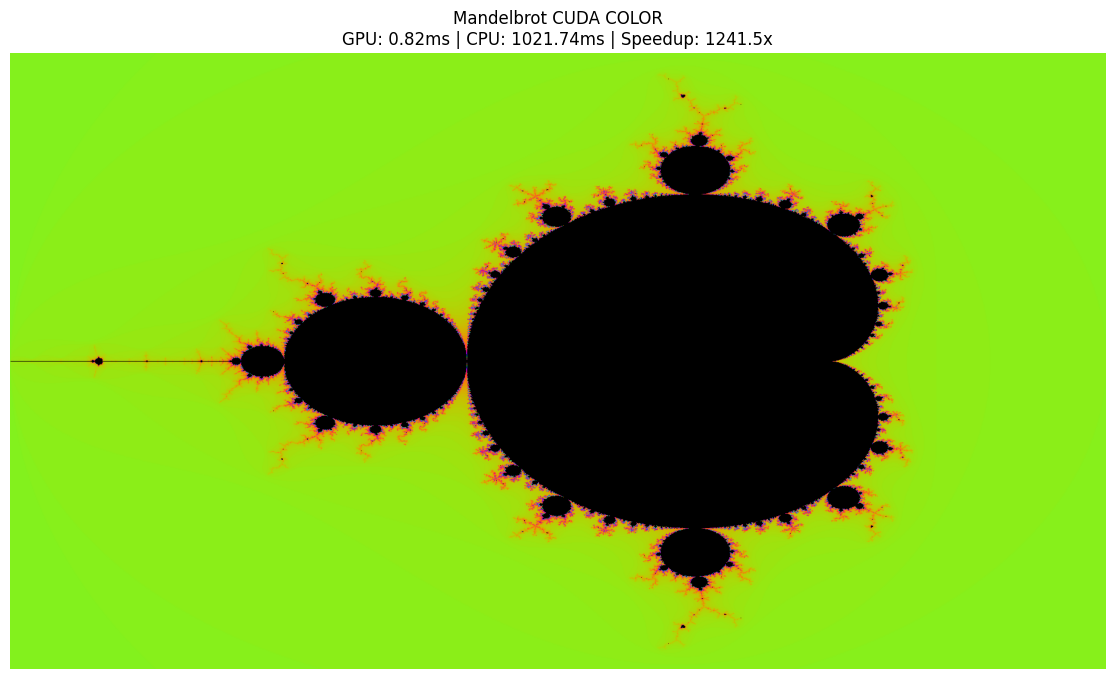

In [29]:
import subprocess, matplotlib.pyplot as plt, re, os
from PIL import Image

# Compilación
!nvcc -O3 mandelbrot_color.cu -o mandelbrot_color

def run_mandel(mode, w=1920, h=1080, iters=500):
    p = subprocess.Popen(['./mandelbrot_color', str(w), str(h), str(iters), str(mode)],
                         stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    out, err = p.communicate()
    match = re.search(r"[-+]?\d*\.\d+|\d+", err.decode())
    return out, float(match.group()) if match else 0.0

print("Generando Mandelbrot en Color...")
raw_gpu, t_gpu = run_mandel(1)
_, t_cpu = run_mandel(0)

img_res = Image.frombytes("RGB", (1920, 1080), raw_gpu)
plt.figure(figsize=(15, 8))
plt.imshow(img_res)
plt.title(f"Mandelbrot CUDA COLOR\nGPU: {t_gpu:.2f}ms | CPU: {t_cpu:.2f}ms | Speedup: {t_cpu/t_gpu:.1f}x")
plt.axis('off')
plt.show()

### **5.3 Reto Creativo: ¡Hackea la Paleta de Colores!**

¿Te has fijado en que el fractal tiene colores verdosos y amarillos? Esto no es magia, es **trigonometría aplicada**. En nuestro kernel, estamos usando la función `sinf()` (seno en punto flotante) para decidir cuánto Rojo (R), Verde (G) y Azul (B) tiene cada píxel basándonos en su número de iteración.

La función que estamos usando es:
$$Color = \sin(frecuencia \cdot t + fase) \cdot 127 + 128$$

#### **Tu Misión:**
Modifica la función `get_color` en el archivo `mandelbrot_color.cu` para cambiar la estética del fractal. Intenta conseguir los siguientes efectos:

1.  **El Fractal de Fuego:** Modifica las fases para que predominen los rojos y naranjas (pista: pon el canal Azul a 0 o con un multiplicador muy bajo).
2.  **El Fractal Eléctrico:** Aumenta la "frecuencia" (el número `0.3f`) a algo como `1.5f`. Verás cómo los ciclos de color se repiten mucho más rápido, creando un efecto de anillos concéntricos muy finos.
3.  **El Fractal "Cyberpunk":** Usa solo los canales Rojo y Azul con fases opuestas para obtener tonos neón, morados y rosas.

> **Instrucción:** Busca esta parte en el código y experimenta con los números:
> ```cpp
> *r = (unsigned char)(sinf(0.3f * t + 0.0f) * 127 + 128);
> *g = (unsigned char)(sinf(0.3f * t + 2.0f) * 127 + 128);
> *b = (unsigned char)(sinf(0.3f * t + 4.0f) * 127 + 128);
> ```

**¿Qué ocurre con el tiempo de ejecución?**
Observa si al añadir más cálculos matemáticos o cambiar las funciones el tiempo de la GPU varía significativamente. Te sorprenderá ver que la GPU es tan potente que apenas nota la diferencia entre calcular un gris simple o un arcoíris trigonométrico.

In [30]:
%%writefile mandelbrot_fuego.cu
// lenguaje: c++
#include <stdio.h>
#include <cuda_runtime.h>
#include <stdlib.h>
#include <math.h>
#include <time.h>

struct Complex {
    float r, i;
    __host__ __device__ Complex(float r, float i) : r(r), i(i) {}
    __host__ __device__ Complex operator+(Complex b) { return Complex(r + b.r, i + b.i); }
    __host__ __device__ Complex operator*(Complex b) { return Complex(r * b.r - i * b.i, r * b.i + i * b.r); }
    __host__ __device__ float magnitude2() { return r * r + i * i; }
};

// Paleta de FUEGO: rojos y naranjas, sin canal azul
__host__ __device__ void get_color(int iter, int max_iters, unsigned char* r, unsigned char* g, unsigned char* b) {
    if (iter == max_iters) {
        *r = *g = *b = 0;
    } else {
        float t = (float)iter / 10.0f;
        *r = (unsigned char)(sinf(0.3f * t + 0.0f) * 127 + 128); // rojo dominante
        *g = (unsigned char)(sinf(0.3f * t + 1.0f) * 60 + 60);   // naranja suave
        *b = 0;                                                     // sin azul
    }
}

__global__ void mandelbrot_kernel(unsigned char* d_out, int w, int h, int max_iters) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x < w && y < h) {
        float cr = -2.0f + 3.0f * x / w;
        float ci = -1.2f + 2.4f * y / h;
        Complex c(cr, ci); Complex z(0, 0);
        int iter = 0;
        while (z.magnitude2() < 4.0f && iter < max_iters) {
            z = z * z + c; iter++;
        }
        int idx = (y * w + x) * 3;
        get_color(iter, max_iters, &d_out[idx], &d_out[idx+1], &d_out[idx+2]);
    }
}

int main(int argc, char** argv) {
    int w = atoi(argv[1]), h = atoi(argv[2]), max_iters = atoi(argv[3]);
    int size = w * h * 3;
    unsigned char *h_out = (unsigned char*)malloc(size);
    unsigned char *d_out; cudaMalloc(&d_out, size);
    dim3 block(16, 16); dim3 grid((w+15)/16, (h+15)/16);
    mandelbrot_kernel<<<grid, block>>>(d_out, w, h, max_iters);
    cudaDeviceSynchronize();
    cudaEvent_t s, e; cudaEventCreate(&s); cudaEventCreate(&e); cudaEventRecord(s);
    mandelbrot_kernel<<<grid, block>>>(d_out, w, h, max_iters);
    cudaEventRecord(e); cudaEventSynchronize(e); float ms; cudaEventElapsedTime(&ms, s, e);
    fprintf(stderr, "%f", ms);
    cudaMemcpy(h_out, d_out, size, cudaMemcpyDeviceToHost);
    cudaFree(d_out);
    fwrite(h_out, sizeof(unsigned char), size, stdout);
    return 0;
}

Overwriting mandelbrot_fuego.cu


In [31]:
%%writefile mandelbrot_cyberpunk.cu
// lenguaje: c++
#include <stdio.h>
#include <cuda_runtime.h>
#include <stdlib.h>
#include <math.h>
#include <time.h>

struct Complex {
    float r, i;
    __host__ __device__ Complex(float r, float i) : r(r), i(i) {}
    __host__ __device__ Complex operator+(Complex b) { return Complex(r + b.r, i + b.i); }
    __host__ __device__ Complex operator*(Complex b) { return Complex(r * b.r - i * b.i, r * b.i + i * b.r); }
    __host__ __device__ float magnitude2() { return r * r + i * i; }
};

// Paleta CYBERPUNK: solo R y B con fases opuestas -> morados, rosas, neón
__host__ __device__ void get_color(int iter, int max_iters, unsigned char* r, unsigned char* g, unsigned char* b) {
    if (iter == max_iters) {
        *r = *g = *b = 0;
    } else {
        float t = (float)iter / 10.0f;
        *r = (unsigned char)(sinf(1.5f * t + 0.0f) * 127 + 128); // rojo con alta frecuencia
        *g = 0;                                                     // verde apagado
        *b = (unsigned char)(sinf(1.5f * t + 3.14f) * 127 + 128); // azul en fase opuesta
    }
}

__global__ void mandelbrot_kernel(unsigned char* d_out, int w, int h, int max_iters) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x < w && y < h) {
        float cr = -2.0f + 3.0f * x / w;
        float ci = -1.2f + 2.4f * y / h;
        Complex c(cr, ci); Complex z(0, 0);
        int iter = 0;
        while (z.magnitude2() < 4.0f && iter < max_iters) {
            z = z * z + c; iter++;
        }
        int idx = (y * w + x) * 3;
        get_color(iter, max_iters, &d_out[idx], &d_out[idx+1], &d_out[idx+2]);
    }
}

int main(int argc, char** argv) {
    int w = atoi(argv[1]), h = atoi(argv[2]), max_iters = atoi(argv[3]);
    int size = w * h * 3;
    unsigned char *h_out = (unsigned char*)malloc(size);
    unsigned char *d_out; cudaMalloc(&d_out, size);
    dim3 block(16, 16); dim3 grid((w+15)/16, (h+15)/16);
    mandelbrot_kernel<<<grid, block>>>(d_out, w, h, max_iters);
    cudaDeviceSynchronize();
    cudaEvent_t s, e; cudaEventCreate(&s); cudaEventCreate(&e); cudaEventRecord(s);
    mandelbrot_kernel<<<grid, block>>>(d_out, w, h, max_iters);
    cudaEventRecord(e); cudaEventSynchronize(e); float ms; cudaEventElapsedTime(&ms, s, e);
    fprintf(stderr, "%f", ms);
    cudaMemcpy(h_out, d_out, size, cudaMemcpyDeviceToHost);
    cudaFree(d_out);
    fwrite(h_out, sizeof(unsigned char), size, stdout);
    return 0;
}

Overwriting mandelbrot_cyberpunk.cu


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


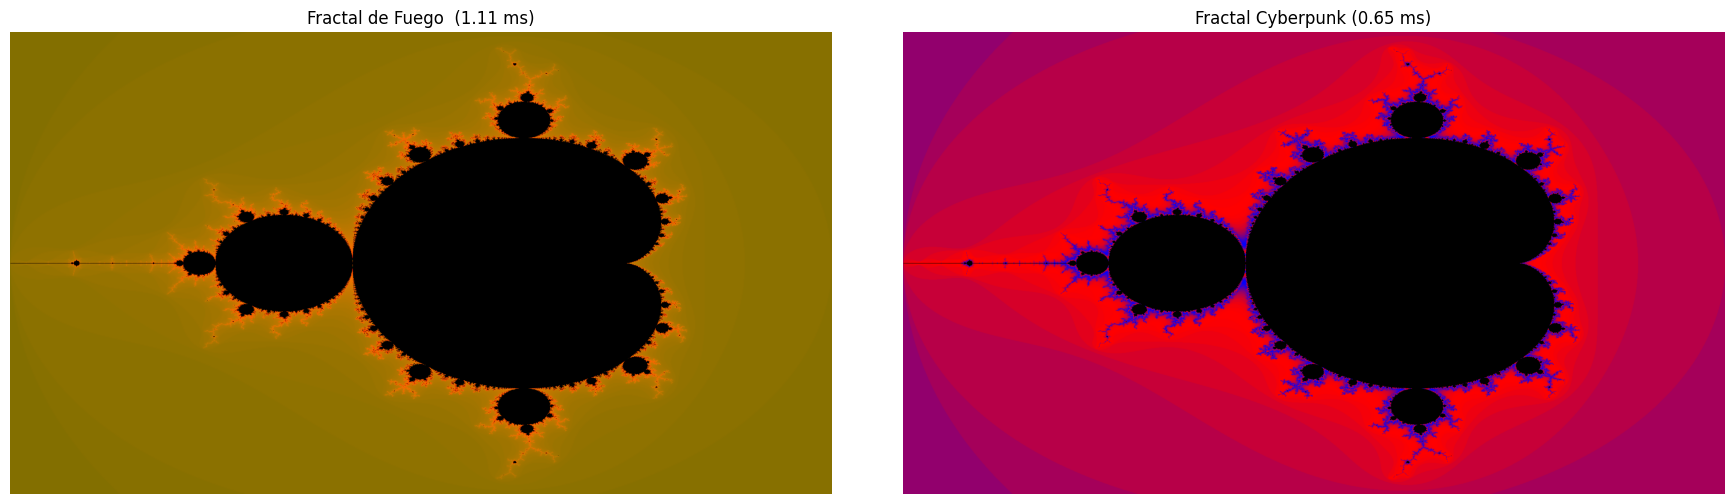

Los tiempos son prácticamente iguales: la GPU procesa las funciones trigonométricas sin apenas coste extra.


In [32]:
import subprocess, matplotlib.pyplot as plt, re
from PIL import Image

# Compilamos las dos variantes creativas
!nvcc -O3 mandelbrot_fuego.cu -o mandelbrot_fuego
!nvcc -O3 mandelbrot_cyberpunk.cu -o mandelbrot_cyberpunk

def run_custom(binary, w=1920, h=1080, iters=500):
    p = subprocess.Popen([f'./{binary}', str(w), str(h), str(iters)],
                         stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    out, err = p.communicate()
    match = re.search(r"[-+]?\d*\.\d+|\d+", err.decode())
    return out, float(match.group()) if match else 0.0

raw_fuego, t_fuego = run_custom('mandelbrot_fuego')
raw_cyber, t_cyber = run_custom('mandelbrot_cyberpunk')

img_fuego = Image.frombytes("RGB", (1920, 1080), raw_fuego)
img_cyber  = Image.frombytes("RGB", (1920, 1080), raw_cyber)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].imshow(img_fuego)
axes[0].set_title(f"Fractal de Fuego  ({t_fuego:.2f} ms)")
axes[0].axis('off')
axes[1].imshow(img_cyber)
axes[1].set_title(f"Fractal Cyberpunk ({t_cyber:.2f} ms)")
axes[1].axis('off')
plt.tight_layout()
plt.show()
print("Los tiempos son prácticamente iguales: la GPU procesa las funciones trigonométricas sin apenas coste extra.")

# 6. Cuestionario para el Informe de Prácticas

Para completar la entrega de esta sesión, responde de forma razonada a las siguientes cuestiones basándote en los experimentos y gráficas obtenidos.

---

### I. Sobre SAXPY y el Control de Hilos
1. **El coste de la transferencia:** En los tamaños de vector más pequeños (10^4), la CPU suele ser competitiva o incluso más rápida que la GPU. ¿Por qué ocurre esto? Explica el concepto de "overhead" o latencia en el bus PCI-Express.
2. **Control de límites:** En tu kernel de SAXPY, incluimos la condición if (i < n). ¿Qué sucedería si lanzamos un bloque de 256 hilos para procesar un vector de solo 200 elementos y olvidamos esa condición? ¿Qué memoria estaríamos corrompiendo?

---

### II. Multiplicación de Matrices (GEMM)
3. **Optimización en CPU:** Has comparado la versión ijk frente a la ikj. Explica brevemente por qué el simple hecho de cambiar el orden de los bucles mejora tanto el rendimiento en la CPU. ¿Cómo afecta esto al uso de la memoria caché? ¿has probado a codificar ijk e ikj en GPU? ¿Tiene sentido?
4. **Análisis de la Gráfica Logarítmica:** Al observar la gráfica, la línea de la GPU suele mantenerse más plana o crecer más lentamente que las de la CPU. ¿Qué significa esto en términos de escalabilidad cuando el problema se hace masivo?

---

### III. El Fractal de Mandelbrot: Cómputo Intensivo
5. **Compute Bound vs Memory Bound:** En el fractal hemos obtenido un Speedup superior a 1000x, mucho mayor que en SAXPY. ¿Por qué la GPU brilla tanto en este ejercicio? (Pista: Compara la cantidad de operaciones matemáticas por cada byte de memoria movido).
6. **Determinismo:** ¿Por qué, a pesar de que la imagen parece orgánica y compleja, todos los alumnos obtienen exactamente el mismo fractal? ¿Qué papel juega la rejilla de píxeles y la fórmula fija Z_{n+1} = Z_n^2 + C?

---

### IV. Reflexión Final y Reto de Color
7. **Trigonometría en la GPU:** Tras modificar la función get_color con funciones seno y coseno, ¿has notado una caída en el rendimiento (ms)? ¿Qué nos dice esto sobre la capacidad de las unidades de cálculo (ALUs) de la GPU para procesar funciones complejas en paralelo?
8. **Conclusión Personal:** Según lo visto en esta práctica, ¿en qué situaciones recomendarías mover un algoritmo de la CPU a la GPU y cuándo crees que no merece la pena el esfuerzo?

---

